# Bivariate Analysis

Bivariate analysis examines the statistical relationship and dependencies between two distinct variables to uncover underlying patterns, correlations, or differences.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


In [5]:
df['ContractType'] = df['ContractType'].str.replace('Month to month', 'Month-to-month')
df['InternetService'] = df['InternetService'].str.replace('fiber optic', 'Fiber optic')
df['Gender'] = df['Gender'].str.capitalize()

### 1. Numerical vs. Numerical Analysis

The evaluation of the direction, magnitude, and functional relationship (linear or non-linear) between two continuous quantitative variables.

Example:

Age vs. Salary — Analyzing how employee age correlates with annual compensation to understand earnings trajectories over a career.

#### AI/ML Usage

* Feature Selection & Multicollinearity: Identifying highly correlated input features ($r > 0.85$) to prevent instability in Linear Regression or Logistic Regression models.

* Regression Modeling: Assessing linear assumptions before training algorithms like Ridge/Lasso regression or Gradient Boosting Trees.

Primary Technique: Scatter Plot (with optional regression line).

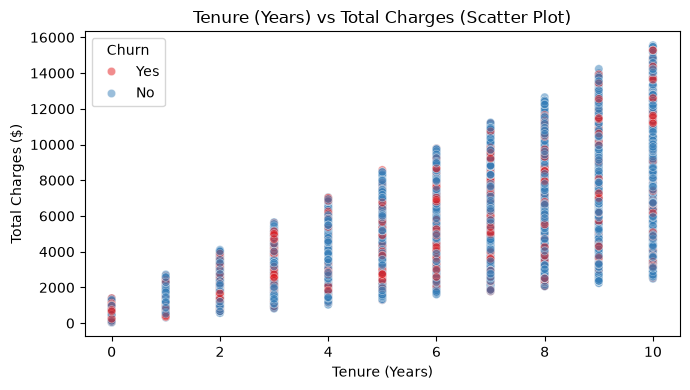

In [7]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='TenureYears', y='TotalCharges', alpha=0.5, hue='Churn', palette='Set1')
plt.title('Tenure (Years) vs Total Charges (Scatter Plot)')
plt.xlabel('Tenure (Years)')
plt.ylabel('Total Charges ($)')
plt.tight_layout()
plt.savefig('scatter_tenure_totalcharges.png')
plt.show()

* Variables Analyzed: TenureYears (Numerical) vs. TotalCharges (Numerical), hue by Churn.

* Key Observations: Demonstrates a strong, direct positive linear correlation ($r = 0.760$). As customer account age increases from 0 to 10 years, total accumulated charges scale proportionally up to $\approx \$15,000$.

* Distribution Patterns: Churned customers (red dots) are distributed across all tenure levels, but customer lifetime spend is primarily driven by tenure duration rather than churn status alone.

* AI/ML & Business Insight: High multicollinearity exists between TenureYears and TotalCharges. Linear models require feature selection or regularization (L1/L2) to prevent variance inflation.

In [9]:
# Correlation numerical vs numerical

corr_matrix = df[['Age', 'TenureYears', 'MonthlyCharges', 'TotalCharges']].corr()
print("Correlation Matrix:")
print(corr_matrix.round(3))

print("\nMean Monthly Charges by Contract Type:")
print(df.groupby('ContractType')['MonthlyCharges'].mean().round(2))

print("\nMean Monthly Charges by Churn:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

print("\nCrosstab InternetService vs Churn %:")
print((pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100).round(2))

Correlation Matrix:
                  Age  TenureYears  MonthlyCharges  TotalCharges
Age             1.000        0.018          -0.007         0.016
TenureYears     0.018        1.000          -0.015         0.760
MonthlyCharges -0.007       -0.015           1.000         0.552
TotalCharges    0.016        0.760           0.552         1.000

Mean Monthly Charges by Contract Type:
ContractType
Month-to-month    70.13
One year          69.84
Two year          70.27
Name: MonthlyCharges, dtype: float64

Mean Monthly Charges by Churn:
Churn
No     70.06
Yes    70.16
Name: MonthlyCharges, dtype: float64

Crosstab InternetService vs Churn %:
Churn               No    Yes
InternetService              
DSL              75.61  24.39
Fiber optic      67.70  32.30
No               76.16  23.84


### 2. Numerical vs. Categorical Analysis

Comparing the distribution, central tendency (mean/median), spread, and outliers of a continuous numerical variable across discrete groups or categories.

Example:

Department vs. Salary — Comparing compensation distributions across Engineering, Marketing, and Sales departments to identify pay disparities.

#### AI/ML Usage

* Target Encoding: Evaluating if a target numerical variable shifts significantly across categorical subgroups.

* Outlier Detection: Identifying anomalies per specific category rather than across the global dataset.

* Hypothesis Testing: Preparing data for ANOVA or Mann-Whitney U statistical tests.

Primary Techniques: Box Plot (shows quartiles/outliers) and Violin Plot (shows probability density).


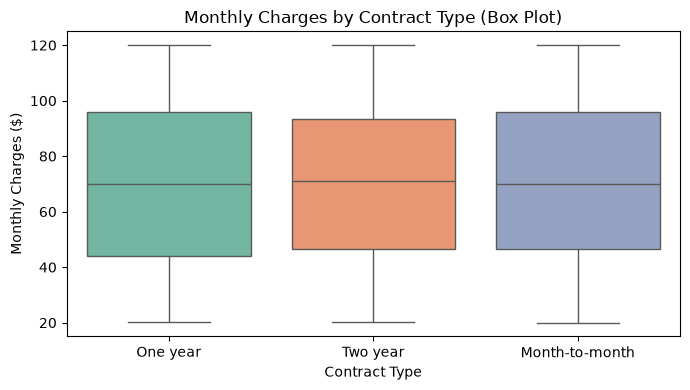

In [11]:
# Numerical vs Categorical: Box Plot (MonthlyCharges across ContractType)

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='ContractType', y='MonthlyCharges',hue='ContractType', palette='Set2')
plt.title('Monthly Charges by Contract Type (Box Plot)')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('boxplot_monthly_contract.png')
plt.show()

* Variables Analyzed: ContractType (Categorical) vs. MonthlyCharges (Numerical).

* Key Observations: The distribution of monthly charges remains stable across all three contract tiers (Month-to-month, One year, and Two year). Median monthly charges for all groups hover around $\$70.00$.

* Spread & Outliers: Interquartile ranges (IQR) span from approximately $\$45.00$ ($Q_1$) to $\$95.00$ ($Q_3$) for all contract types, with no extreme statistical outliers.

* AI/ML & Business Insight: Pricing tier selection is independent of commitment length; customers on premium or budget plans enroll in short-term and long-term contracts in similar proportions.

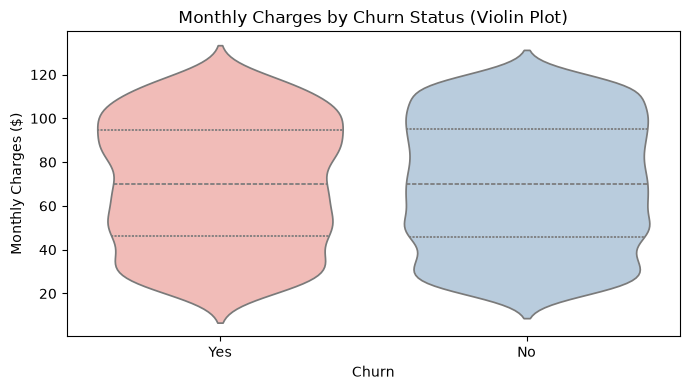

In [12]:
# Numerical vs Categorical: Violin Plot (MonthlyCharges across Churn)

plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', legend=False, palette='Pastel1', inner='quartile')
plt.title('Monthly Charges by Churn Status (Violin Plot)')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('violin_monthly_churn.png')
plt.show()

* Variables Analyzed: Churn (Categorical) vs. MonthlyCharges (Numerical).
  
* Key Observations: Both churned and retained customer groups display nearly identical central tendencies:

          * Retained (No): Mean = $\$70.06$, Median = $\$70.18$

          * Churned (Yes): Mean = $\$70.16$, Median = $\$70.14$

  

* Shape & Density: Displays a distinct bimodal density distribution for both classes, showing concentration clusters around low rates ($\$20-\$30$) and higher rates ($\$80-\$100$).

* AI/ML & Business Insight: MonthlyCharges alone is not a strong linear separator for churn prediction. Predictive models must leverage feature interactions (e.g., charges combined with service type or customer support calls).

### 3. Categorical vs. Categorical Analysis

Examining the co-occurrence, joint frequency, and dependency between two discrete qualitative variables.

Example: 

Product Category vs. Customer Churn — Assessing whether purchase preferences (e.g., Electronics vs. Apparel) correlate with customer retention status (Churned vs. Retained).

#### AI/ML Usage

* Independence Testing: Running Chi-Square ($\chi^2$) tests to drop redundant or independent categorical features before feeding them into classification algorithms.

* Tree Splitting Metrics: Assisting in understanding Information Gain or Gini Impurity calculations in Decision Trees.

Primary Techniques: Cross Tabulation (Contingency Table) and Grouped Bar Chart.

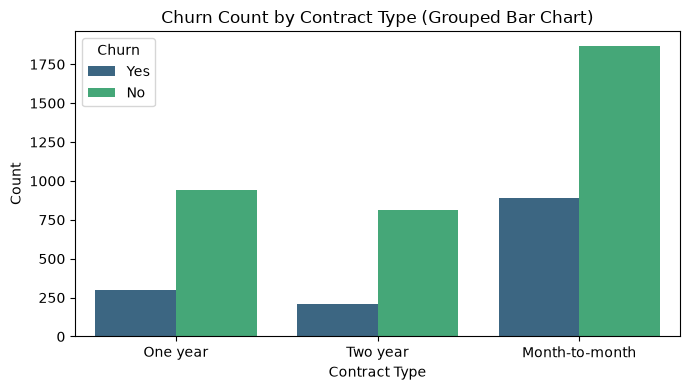

In [13]:
# Categorical vs Categorical: Grouped Bar Chart (ContractType vs Churn)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='ContractType', hue='Churn', palette='viridis')
plt.title('Churn Count by Contract Type (Grouped Bar Chart)')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('grouped_bar_contract_churn.png')
plt.show()

* Variables Analyzed: ContractType (Categorical) vs. Churn (Categorical).
  
* Key Observations: Month-to-month contracts generate the highest absolute churn volume and the highest relative churn rate across groups:

             * Month-to-month: 889 churned out of 2,757 customers (32.25% churn rate)

             * One year: 298 churned out of 1,240 customers (24.03% churn rate)

             * Two year: 210 churned out of 1,023 customers (20.53% churn rate)

* AI/ML & Business Insight: ContractType is one of the most informative categorical predictors for churn modeling. Converting month-to-month subscribers to multi-year contracts directly reduces churn risk by over $11\%$.

In [14]:
# Cross Tabulation: ContractType vs Churn

crosstab_res = pd.crosstab(df['ContractType'], df['Churn'], margins=True, normalize='index') * 100
print("Cross Tabulation (ContractType vs Churn %):")
print(crosstab_res.round(2))

Cross Tabulation (ContractType vs Churn %):
Churn              No    Yes
ContractType                
Month-to-month  67.75  32.25
One year        75.97  24.03
Two year        79.47  20.53
All             72.17  27.83
